<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day38_EDA(Feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

df = pd.read_excel(url, header=1)

print(f"Dataset: {df.shape[0]:,} loans, {df.shape[1]} features")
df.head()

Dataset: 30,000 loans, 25 features


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
print("Columns")
print(df.columns.tolist())
print(f"Data Types:")
print(df.dtypes.value_counts())

print("\n--- Inspecting potential categorical columns (currently int64) ---")
potential_categorical = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0']
for col in potential_categorical:
    if col in df.columns:
        print(f"\nUnique values for {col}:")
        print(df[col].value_counts().sort_index())

Columns
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']
Data Types:
int64    25
Name: count, dtype: int64

--- Inspecting potential categorical columns (currently int64) ---

Unique values for SEX:
SEX
1    11888
2    18112
Name: count, dtype: int64

Unique values for EDUCATION:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Unique values for MARRIAGE:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Unique values for PAY_0:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


In [4]:
# Checking for target variable
potential_targets = ['loan_status', 'default', 'not.fully.paid', 'target', 'Default', 'loan_default']
target_col = None

for col in potential_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    # Check for binary columns
    for col in df.columns:

        if df[col].nunique() == 2:
            print(f"Potential target: {col} — {df[col].value_counts().to_dict()}")
else:
    print(f"Target column: {target_col}")
    print(df[target_col].value_counts())

Potential target: SEX — {2: 18112, 1: 11888}
Potential target: default payment next month — {0: 23364, 1: 6636}


In [5]:
#Setting the target
target_col = 'default payment next month'

print(f"Using Target: {target_col}")
print(f"Default rate: {df[target_col].mean():.2%}")

Using Target: default payment next month
Default rate: 22.12%


Data Overview

In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Rows: 30,000
Columns: 25
Memory: 6.0 MB


In [7]:
#Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
  print("Missing Values")
  print(missing_df)
else:
  print("No Missing Values")

No Missing Values


In [8]:
potential_categorical = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in potential_categorical:
    if col in df.columns:
        df[col] = df[col].astype('object')

# Re-run the categorical and numerical column separation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# removing target from the features
if target_col in numeric_cols:
  numeric_cols.remove(target_col)
if target_col in categorical_cols:
  categorical_cols.remove(target_col)

print(f"Numeric Columns: {len(numeric_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")

Numeric Columns: 15
Categorical Columns: 9


In [9]:
df.describe().round(2)

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,35.49,51223.33,49179.08,47013.15,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,9.22,73635.86,71173.77,69349.39,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,21.00,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,28.00,3558.75,2984.75,2666.25,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,34.00,22381.50,21200.00,20088.50,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,41.00,67091.00,64006.25,60164.75,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,79.00,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


Target Analysis

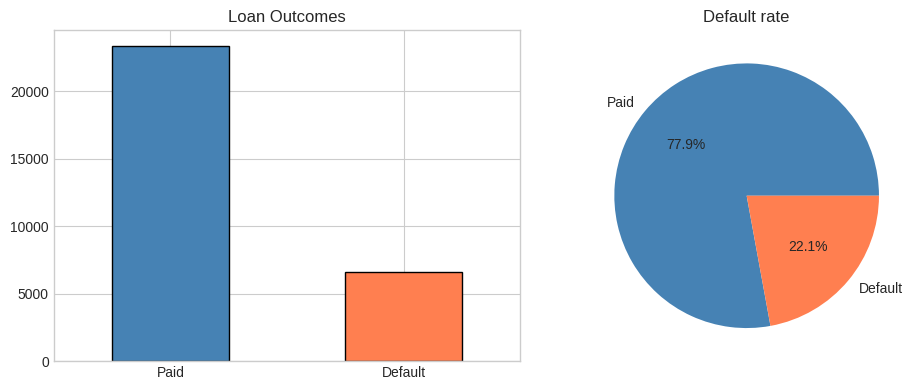


Class imbalance ratio: 1: 3.5


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title("Loan Outcomes")
axes[0].set_xlabel("")
axes[0].set_xticklabels(['Paid', 'Default'], rotation=0)

df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'coral'], labels=['Paid', 'Default'])
axes[1].set_title("Default rate")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio: 1: {(1-df[target_col].mean())/df[target_col].mean():.1f}")


Numeric feature Analysis

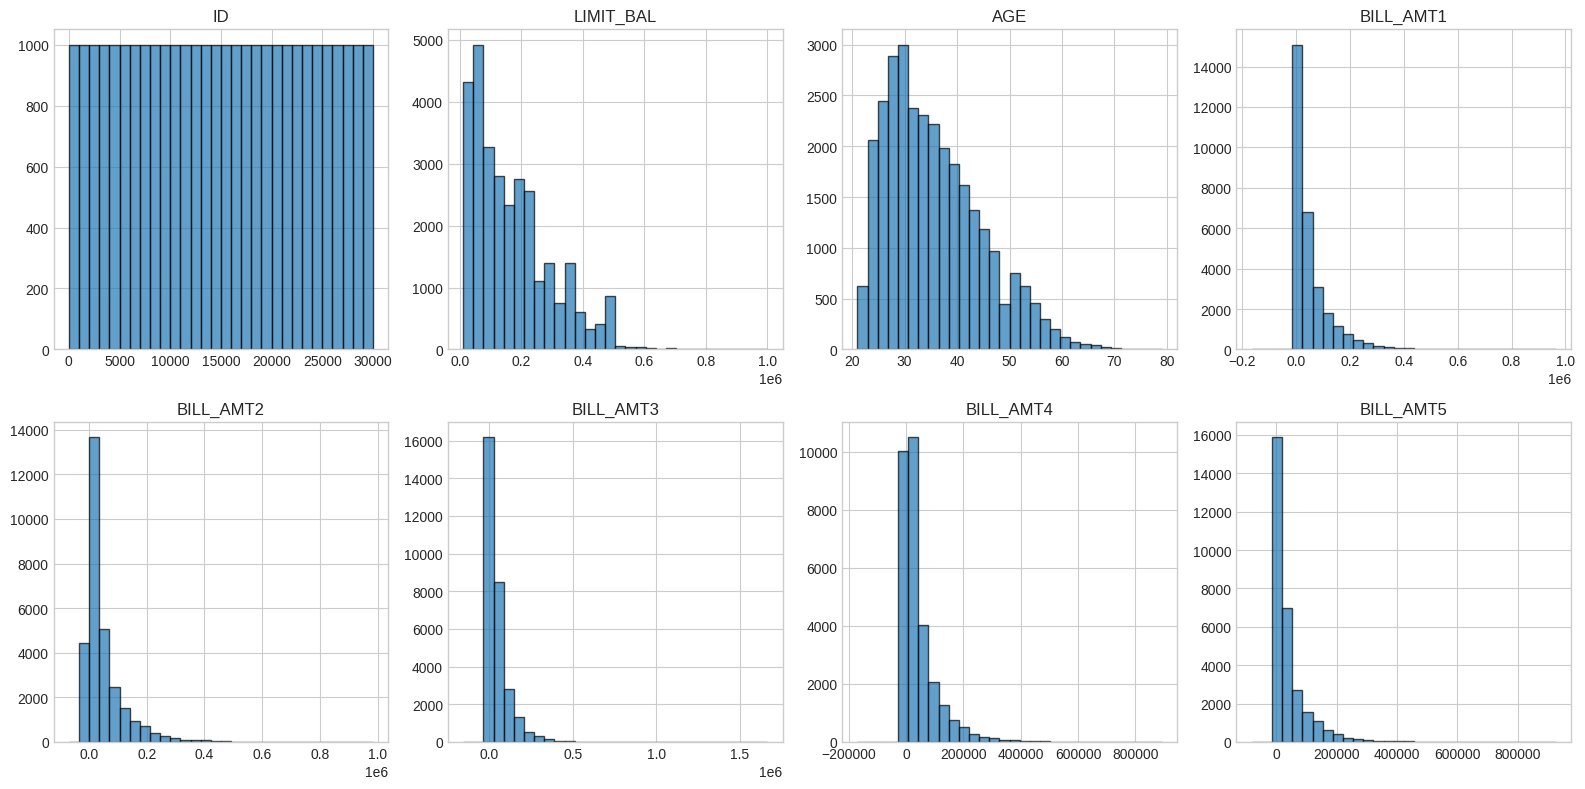

In [11]:
key_numeric = numeric_cols[:8]  # First 8 numeric features

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    if i < len(axes):
        df[col].hist(bins=30, ax=axes[i], edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

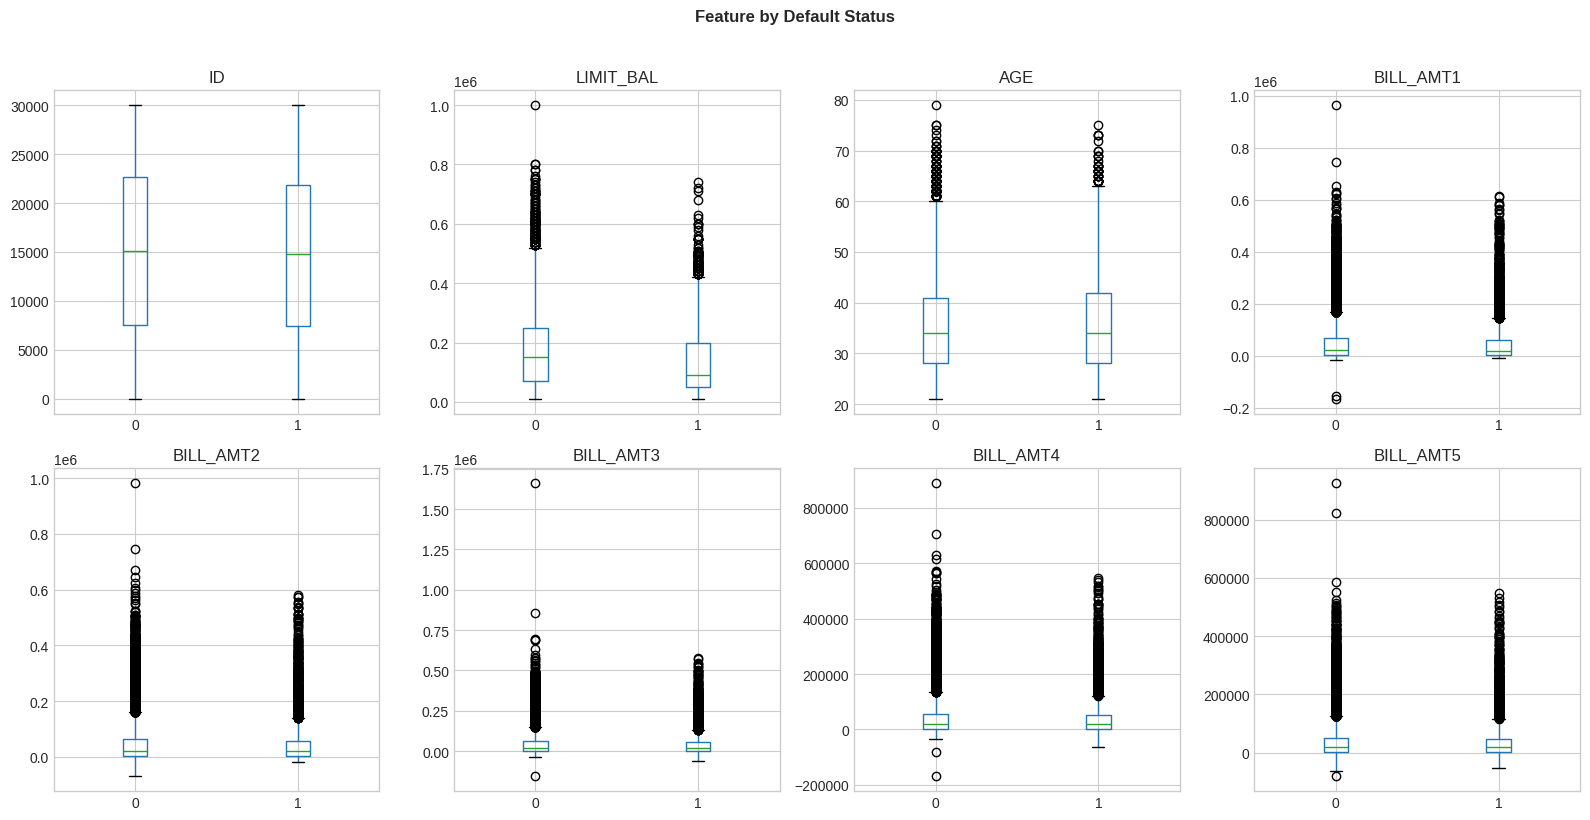

In [12]:
# Numeric features of default status
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
  if i < len(axes):
    df.boxplot(column=col, by=target_col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Feature by Default Status', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

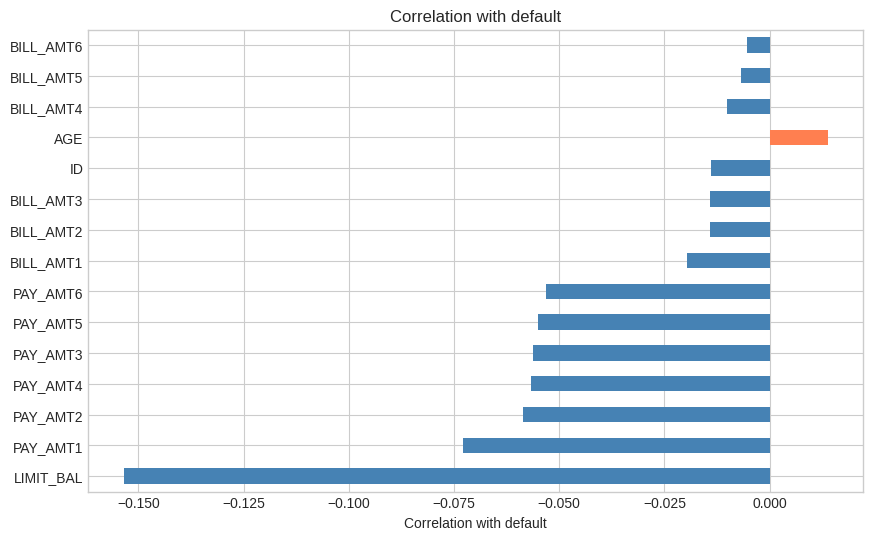

TOP 5 Correlated features:
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
PAY_AMT3    -0.056
Name: default payment next month, dtype: float64


In [13]:
#correlation with target
correlations = df[numeric_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['coral' if x > 0 else 'steelblue' for x in correlations])
plt.xlabel('Correlation with default')
plt.title('Correlation with default')
plt.show()

print('TOP 5 Correlated features:')
print(correlations.head().round(3))

Categorical Feature Analysis

In [14]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())



--- SEX ---
SEX
2    18112
1    11888
Name: count, dtype: int64

--- EDUCATION ---
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

--- MARRIAGE ---
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

--- PAY_0 ---
PAY_0
0     14737
-1     5686
1      3688
-2     2759
2      2667
3       322
4        76
5        26
8        19
6        11
7         9
Name: count, dtype: int64

--- PAY_2 ---
PAY_2
0     15730
-1     6050
2      3927
-2     3782
3       326
4        99
1        28
5        25
7        20
6        12
8         1
Name: count, dtype: int64

--- PAY_3 ---
PAY_3
0     15764
-1     5938
-2     4085
2      3819
3       240
4        76
7        27
6        23
5        21
1         4
8         3
Name: count, dtype: int64

--- PAY_4 ---
PAY_4
0     16455
-1     5687
-2     4348
2      3159
3       180
4        69
7        58
5        35
6         5
1         2
8         2
Name: count, dty

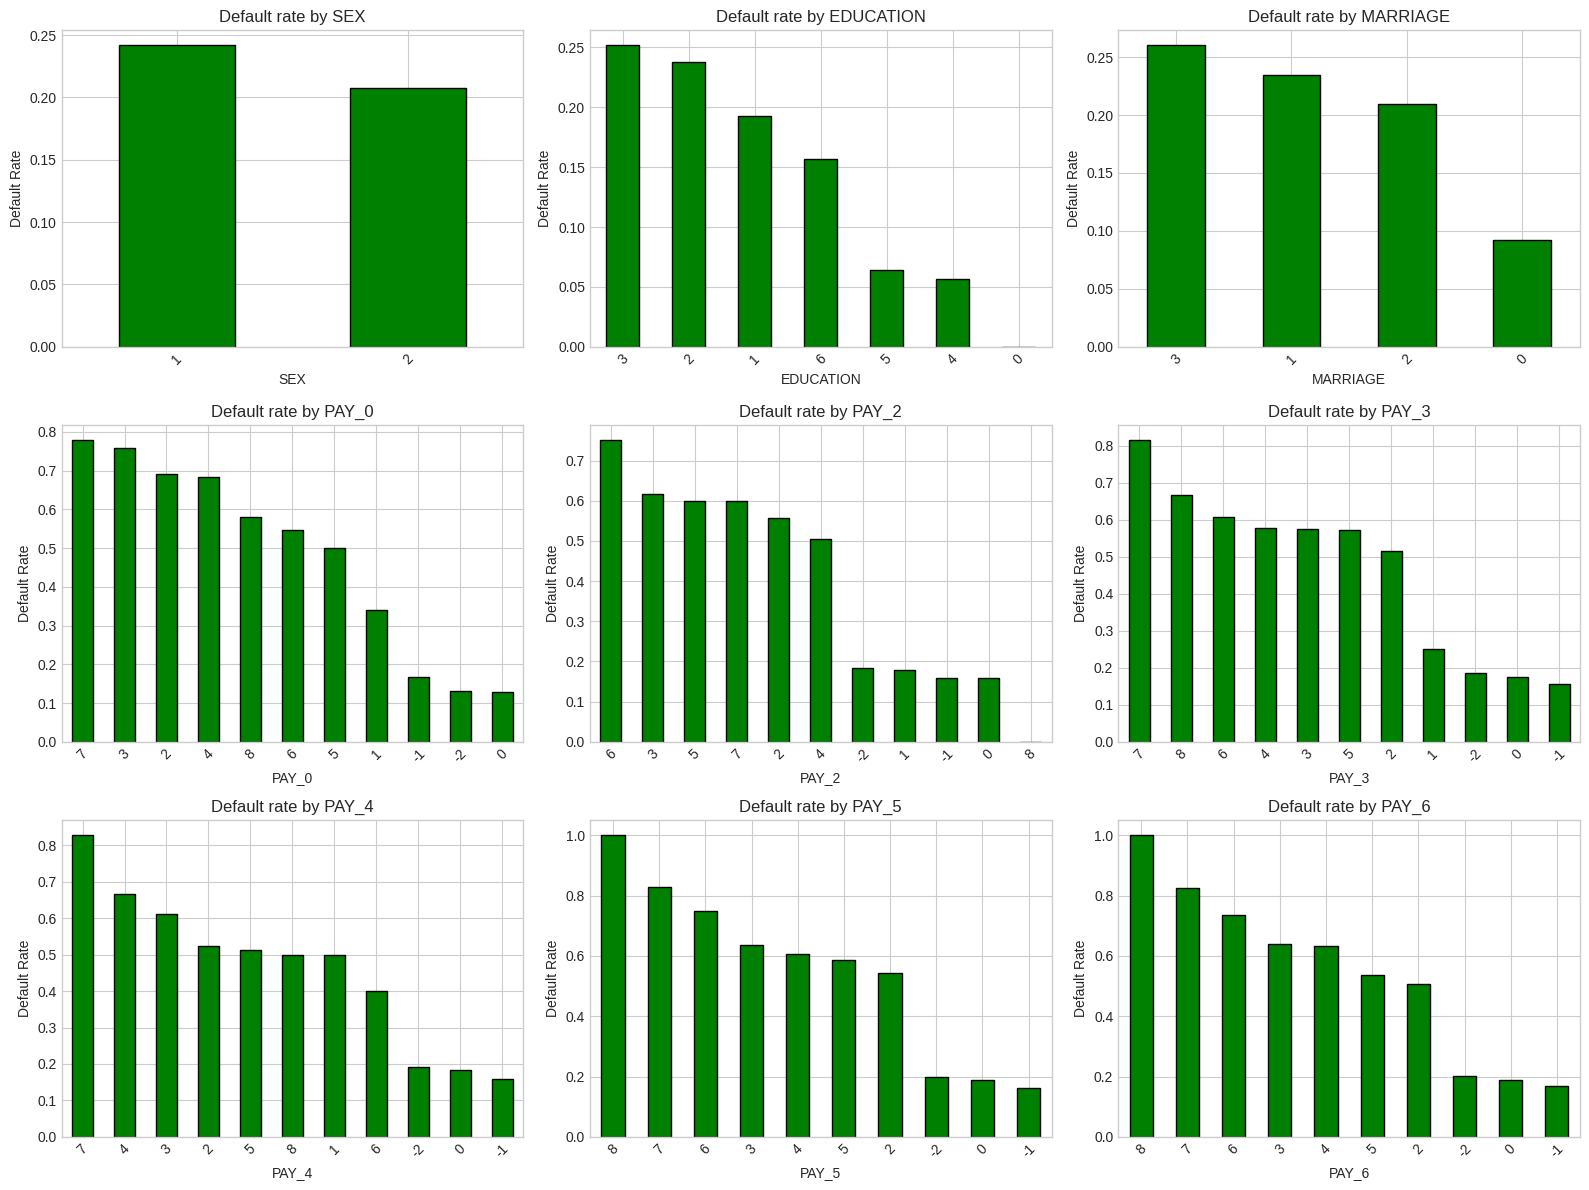

In [15]:
#Default rate by categorical features
num_categorical = len(categorical_cols)
# Determine grid size for subplots
n_rows = (num_categorical + 2) // 3
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
  if i < len(axes):
    default_rates = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    default_rates.plot(kind='bar', ax=axes[i], color='green', edgecolor='black')
    axes[i].set_title(f"Default rate by {col}")
    axes[i].set_ylabel("Default Rate")
    axes[i].tick_params(axis='x', rotation=45)

# Hiding any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Correlation heatmap

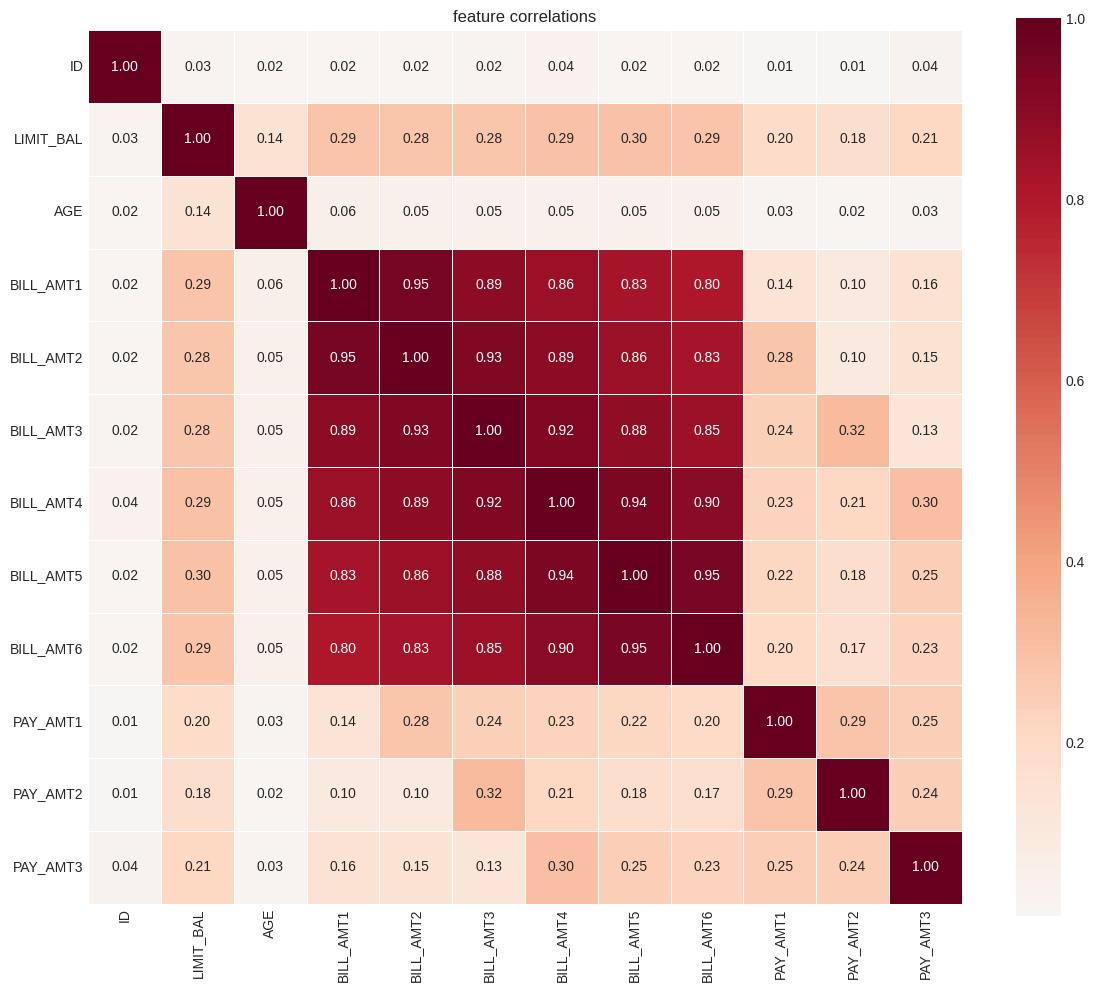

In [16]:
corr_cols = numeric_cols[:12]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', center=0, square=True, linewidths=0.5)
plt.title('feature correlations')
plt.tight_layout()
plt.show()

In [17]:
#Highly correlated features
high_corr = []
for i in range(len(corr_matrix.columns)):
  for j in range(i+1, len(corr_matrix.columns)):
    if abs(corr_matrix.iloc[i, j]) > 0.7:
      high_corr.append({
          'feature 1': corr_matrix.columns[i],
          'feature 2': corr_matrix.columns[j],
          'correlation': corr_matrix.iloc[i, j]
      })

if high_corr:
  print("Highly correlated features:")
  print(pd.DataFrame(high_corr).round(3))
else:
  print("No highly correlated features found.")

Highly correlated features:
    feature 1  feature 2  correlation
0   BILL_AMT1  BILL_AMT2        0.951
1   BILL_AMT1  BILL_AMT3        0.892
2   BILL_AMT1  BILL_AMT4        0.860
3   BILL_AMT1  BILL_AMT5        0.830
4   BILL_AMT1  BILL_AMT6        0.803
5   BILL_AMT2  BILL_AMT3        0.928
6   BILL_AMT2  BILL_AMT4        0.892
7   BILL_AMT2  BILL_AMT5        0.860
8   BILL_AMT2  BILL_AMT6        0.832
9   BILL_AMT3  BILL_AMT4        0.924
10  BILL_AMT3  BILL_AMT5        0.884
11  BILL_AMT3  BILL_AMT6        0.853
12  BILL_AMT4  BILL_AMT5        0.940
13  BILL_AMT4  BILL_AMT6        0.901
14  BILL_AMT5  BILL_AMT6        0.946


Feature Engineering

In [18]:
df_eng = df.copy()

print("Available columns:")
print(df_eng.columns.tolist())

Available columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [19]:
bill_amt_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Ensure PAY_X columns are numeric for calculation
for col in pay_status_cols:
    df_eng[col] = pd.to_numeric(df_eng[col], errors='coerce').fillna(0)

# 1. Total Bill Amount
df_eng['Total_Bill_Amount'] = df_eng[bill_amt_cols].sum(axis=1)
print("Created: Total_Bill_Amount")

# 2. Total Payment Amount
df_eng['Total_Pay_Amount'] = df_eng[pay_amt_cols].sum(axis=1)
print("Created: Total_Pay_Amount")

# 3. Average Bill Amount
df_eng['Avg_Bill_Amount'] = df_eng[bill_amt_cols].mean(axis=1)
print("Created: Avg_Bill_Amount")

# 4. Average Payment Amount
df_eng['Avg_Pay_Amount'] = df_eng[pay_amt_cols].mean(axis=1)
print("Created: Avg_Pay_Amount")

# 5. Remaining Bill (latest month)
df_eng['Remaining_Bill'] = df_eng['BILL_AMT1'] - df_eng['PAY_AMT1']
print("Created: Remaining_Bill")

# 6. Payment Ratio (avoid division by zero)
df_eng['Payment_Ratio'] = df_eng['Total_Pay_Amount'] / (df_eng['Total_Bill_Amount'] + 1e-6)
print("Created: Payment_Ratio")

# 7. Number of Payment Delays (count how many PAY_X are > 0)
df_eng['Num_Payment_Delays'] = (df_eng[pay_status_cols] > 0).sum(axis=1)
print("Created: Num_Payment_Delays")

# 8. Debt to Limit Ratio (avoid division by zero)
df_eng['Debt_to_Limit_Ratio'] = df_eng['Total_Bill_Amount'] / (df_eng['LIMIT_BAL'] + 1e-6)
print("Created: Debt_to_Limit_Ratio")

# 9. Age Group
df_eng['Age_Group'] = pd.cut(df_eng['AGE'],
                             bins=[0, 25, 35, 45, 55, 65, np.inf],
                             labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'],
                             right=False)
print("Created: Age_Group")


print(f"\nNew DataFrame shape: {df_eng.shape}")
print("New features created!")


Created: Total_Bill_Amount
Created: Total_Pay_Amount
Created: Avg_Bill_Amount
Created: Avg_Pay_Amount
Created: Remaining_Bill
Created: Payment_Ratio
Created: Num_Payment_Delays
Created: Debt_to_Limit_Ratio
Created: Age_Group

New DataFrame shape: (30000, 34)
New features created!


In [20]:
# Log transformations for skewed features
skewed_features = []
for col in numeric_cols:
    if df_eng[col].min() >= 0:  # Only for non-negative
        skewness = df_eng[col].skew()
        if abs(skewness) > 1:
            skewed_features.append((col, skewness))
            df_eng[f'log_{col}'] = np.log1p(df_eng[col])

if skewed_features:
    print(f"\nLog-transformed {len(skewed_features)} skewed features:")
    for feat, skew in skewed_features[:5]:
        print(f"  {feat}: skewness = {skew:.2f}")


Log-transformed 6 skewed features:
  PAY_AMT1: skewness = 14.67
  PAY_AMT2: skewness = 30.45
  PAY_AMT3: skewness = 17.22
  PAY_AMT4: skewness = 12.90
  PAY_AMT5: skewness = 11.13


In [21]:
new_features = [col for col in df_eng.columns if col not in df.columns]
print(f"\nTotal new features: {len(new_features)}")
print(new_features)


Total new features: 15
['Total_Bill_Amount', 'Total_Pay_Amount', 'Avg_Bill_Amount', 'Avg_Pay_Amount', 'Remaining_Bill', 'Payment_Ratio', 'Num_Payment_Delays', 'Debt_to_Limit_Ratio', 'Age_Group', 'log_PAY_AMT1', 'log_PAY_AMT2', 'log_PAY_AMT3', 'log_PAY_AMT4', 'log_PAY_AMT5', 'log_PAY_AMT6']


Handle Categorical Variables

In [23]:
df_processed = df_eng.copy()

label_encoders = {}
for col in categorical_cols:
  le = LabelEncoder()
  df_processed[col] = le.fit_transform(df_processed[col].astype(str))
  label_encoders[col] = le
  print(f"Encoded {col}: {len(le.classes_)} classes")

#encoding for the new categorical features as well
for col in df_processed.select_dtypes(include=['object', 'category']).columns:
  if col not in label_encoders:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col]).astype(int)
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} classes")

Encoded SEX: 2 classes
Encoded EDUCATION: 7 classes
Encoded MARRIAGE: 4 classes
Encoded PAY_0: 11 classes
Encoded PAY_2: 11 classes
Encoded PAY_3: 11 classes
Encoded PAY_4: 11 classes
Encoded PAY_5: 10 classes
Encoded PAY_6: 10 classes
Encoded Age_Group: 6 classes


In [25]:
#Handling missing values
#check
missing_after = df_processed.isnull().sum()
missing_after = missing_after[missing_after > 0]

if len(missing_after) > 0:
    print("Remaining missing values:")
    print(missing_after)

    for col in missing_after.index:
        if df_processed[col].dtype in ['float64', 'int64']:
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())
        else:
            df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])
else:
    print("No missing values remaining")

No missing values remaining


In [27]:
#preparing the final dataset
feature_cols = [col for col in df_processed.columns if col != target_col]

x = df_processed[feature_cols].select_dtypes(include=['int64', 'float64'])
y = df_processed[target_col]

print(f"X shape: {x.shape}")
print(f"Y shape: {y.shape}")
print(f"deafult rate: {y.mean()*100:.2f}%")

X shape: (30000, 39)
Y shape: (30000,)
deafult rate: 22.12%


In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set shape: {x_train.shape[0]:,}")
print(f"Test set shape: {x_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test deafult rate: {y_test.mean()*100:.2f}%")

Train set shape: 24,000
Test set shape: 6,000
Train default rate: 22.12%
Test deafult rate: 22.12%


In [29]:
print('Feature list:')
for i, col in enumerate(x.columns, 1):
  print(f"  {i},  {col}")

Feature list:
  1,  ID
  2,  LIMIT_BAL
  3,  SEX
  4,  EDUCATION
  5,  MARRIAGE
  6,  AGE
  7,  PAY_0
  8,  PAY_2
  9,  PAY_3
  10,  PAY_4
  11,  PAY_5
  12,  PAY_6
  13,  BILL_AMT1
  14,  BILL_AMT2
  15,  BILL_AMT3
  16,  BILL_AMT4
  17,  BILL_AMT5
  18,  BILL_AMT6
  19,  PAY_AMT1
  20,  PAY_AMT2
  21,  PAY_AMT3
  22,  PAY_AMT4
  23,  PAY_AMT5
  24,  PAY_AMT6
  25,  Total_Bill_Amount
  26,  Total_Pay_Amount
  27,  Avg_Bill_Amount
  28,  Avg_Pay_Amount
  29,  Remaining_Bill
  30,  Payment_Ratio
  31,  Num_Payment_Delays
  32,  Debt_to_Limit_Ratio
  33,  Age_Group
  34,  log_PAY_AMT1
  35,  log_PAY_AMT2
  36,  log_PAY_AMT3
  37,  log_PAY_AMT4
  38,  log_PAY_AMT5
  39,  log_PAY_AMT6


Baseline model

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [36]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

baseline = LogisticRegression(random_state=42, max_iter=1000)
baseline.fit(x_train_scaled, y_train)

y_pred = baseline.predict(x_test_scaled)
y_prob = baseline.predict_proba(x_test_scaled)[:, 1]

print("Baseline Logistic Regression Metrics:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Baseline Logistic Regression Metrics:
  Accuracy: 0.8075
  Precision: 0.6503
  Recall: 0.2803
  F1 Score: 0.3918
  ROC-AUC: 0.7508


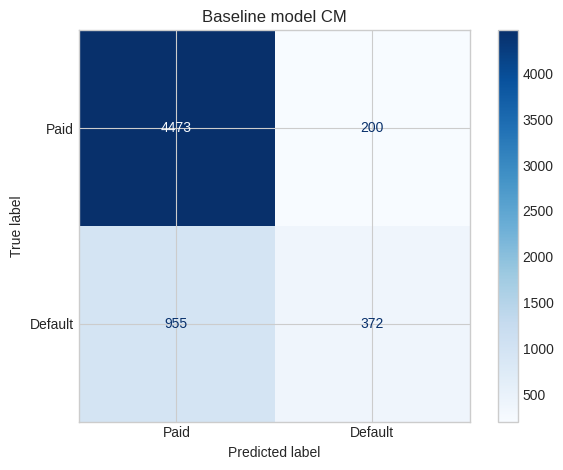


True Negatives (Paid correctly): 4,473
False Positives (Paid as Default): 200
False Negatives (Default as Paid): 955
True Positives (Default correctly): 372


In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Paid', 'Default'])
disp.plot(cmap='Blues')
plt.title("Baseline model CM")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (Paid correctly): {tn:,}")
print(f"False Positives (Paid as Default): {fp:,}")
print(f"False Negatives (Default as Paid): {fn:,}")
print(f"True Positives (Default correctly): {tp:,}")

In [41]:
# Save for next notebook
processed_data = {
    'x_train': x_train,
    'x_test': x_test,
    'y_train': y_train,
    'y_test': y_test,
    'feature_names': x.columns.tolist(),
    'target_col': target_col
}

import pickle
with open('processed_data.pkl', 'wb') as f:
    pickle.dump(processed_data, f)

print("Data saved to 'processed_data.pkl'")

Data saved to 'processed_data.pkl'
